**Exploratory Data Analysis on Chilli Plant Disease Dataset**                                     
We mounted Google Drive to access the chilli plant datasets stored remotely for analysis.

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Data Loading & Structure Creation**                                                
We converted image dataset into structured tabular format using Pandas for easier EDA.                             
We create a table where each row contains the image path and its corresponding label.

In [25]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from google.colab import drive

# Mount Drive
drive.mount('/content/drive')

# Updated Correct Paths
path1 = '/content/drive/MyDrive/Colab Notebooks/Chilli Plant Dataset/Chili Leaf Disease Original Dataset'
path2 = '/content/drive/MyDrive/Colab Notebooks/Chilli Plant Dataset/Chili Growth Stage Original Dataset'

def load_data_info(root_path):
    data = []
    if not os.path.exists(root_path):
        print(f"⚠️ Warning: {root_path} not found.")
        return pd.DataFrame()
    for category in sorted(os.listdir(root_path)):
        cat_path = os.path.join(root_path, category)
        if os.path.isdir(cat_path):
            images = [f for f in os.listdir(cat_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            for img in images:
                data.append({'Class': category, 'Path': os.path.join(cat_path, img)})
    return pd.DataFrame(data)

df_disease = load_data_info(path1)
df_growth = load_data_info(path2)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Core EDA Operations**                                         
We analyzed class distribution to check dataset balance, which is critical for model performance.         

We visualized sample images to understand intra-class variation and visual patterns in the dataset.
                                      


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 1856 images from Chili Leaf Disease Original Dataset
Loaded 1714 images from Chili Growth Stage Original Dataset

Dataset: Leaf Disease Dataset
Total Images: 1856

                  Class  Image Count  Percentage (%)
0          Healthy Leaf          458           24.68
1  Nutrition Deficiency          444           23.92
2            Curl Virus          423           22.79
3            White spot          195           10.51
4  Cercospora Leaf Spot          180            9.70
5        Bacterial Spot          156            8.41

Dataset: Growth Stage Dataset
Total Images: 1714

          Class  Image Count  Percentage (%)
0     Dry chili          410           23.92
1        Flower          397           23.16
2  Rotten Chili          379           22.11
3   Green Chili          328           19.14
4     Red Chili          200           11.67


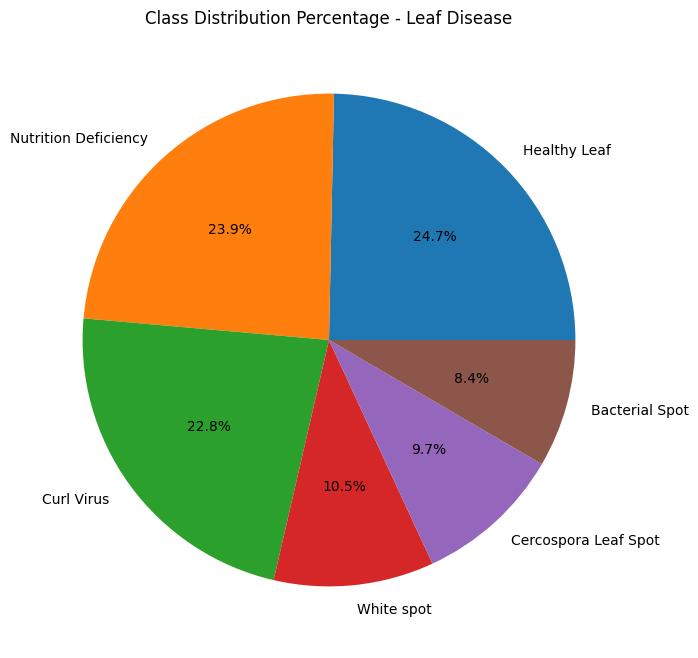

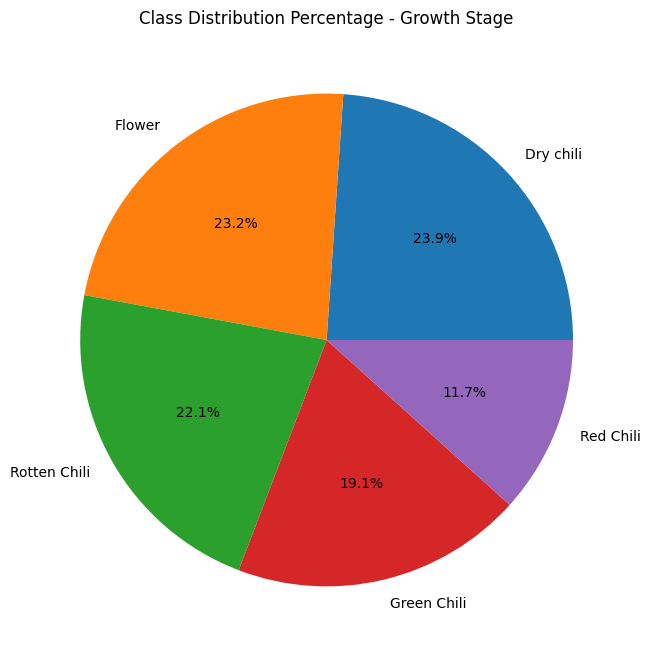

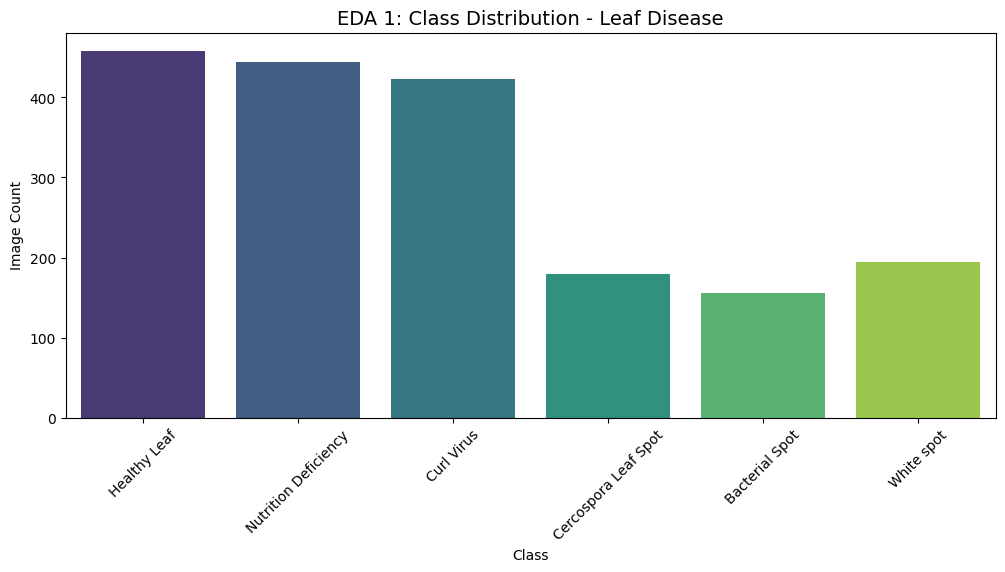

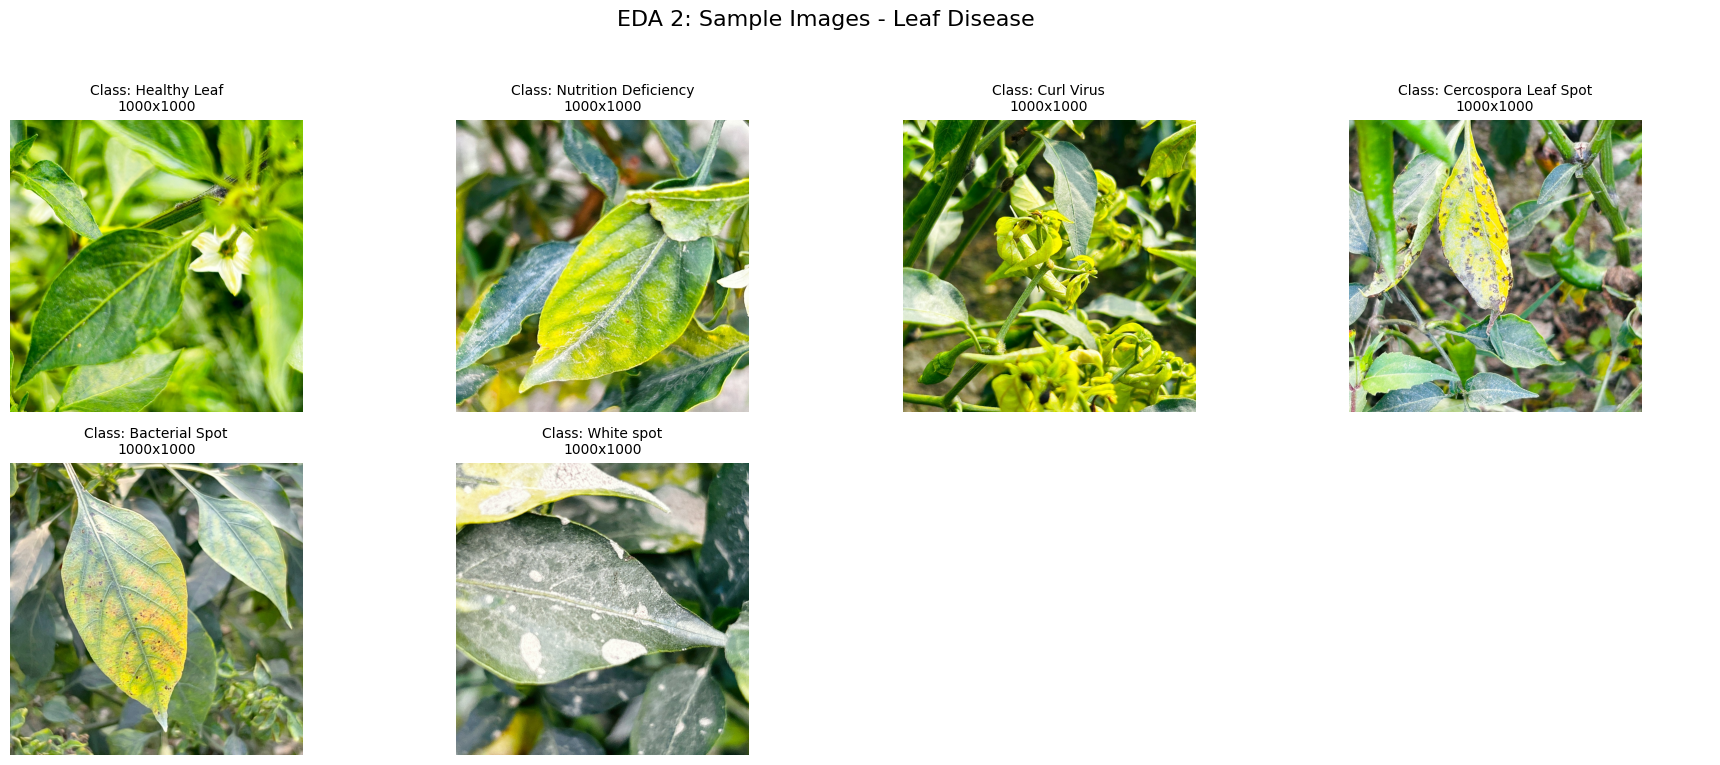

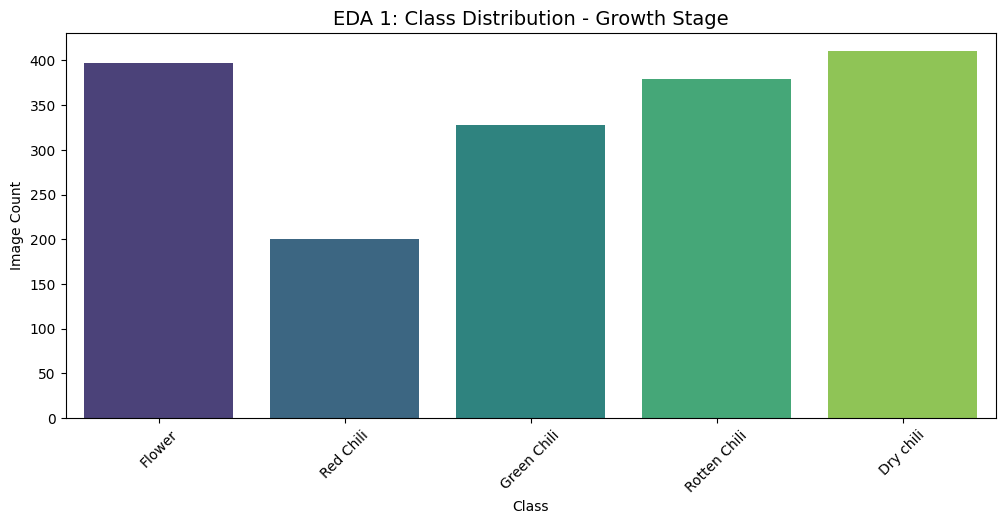

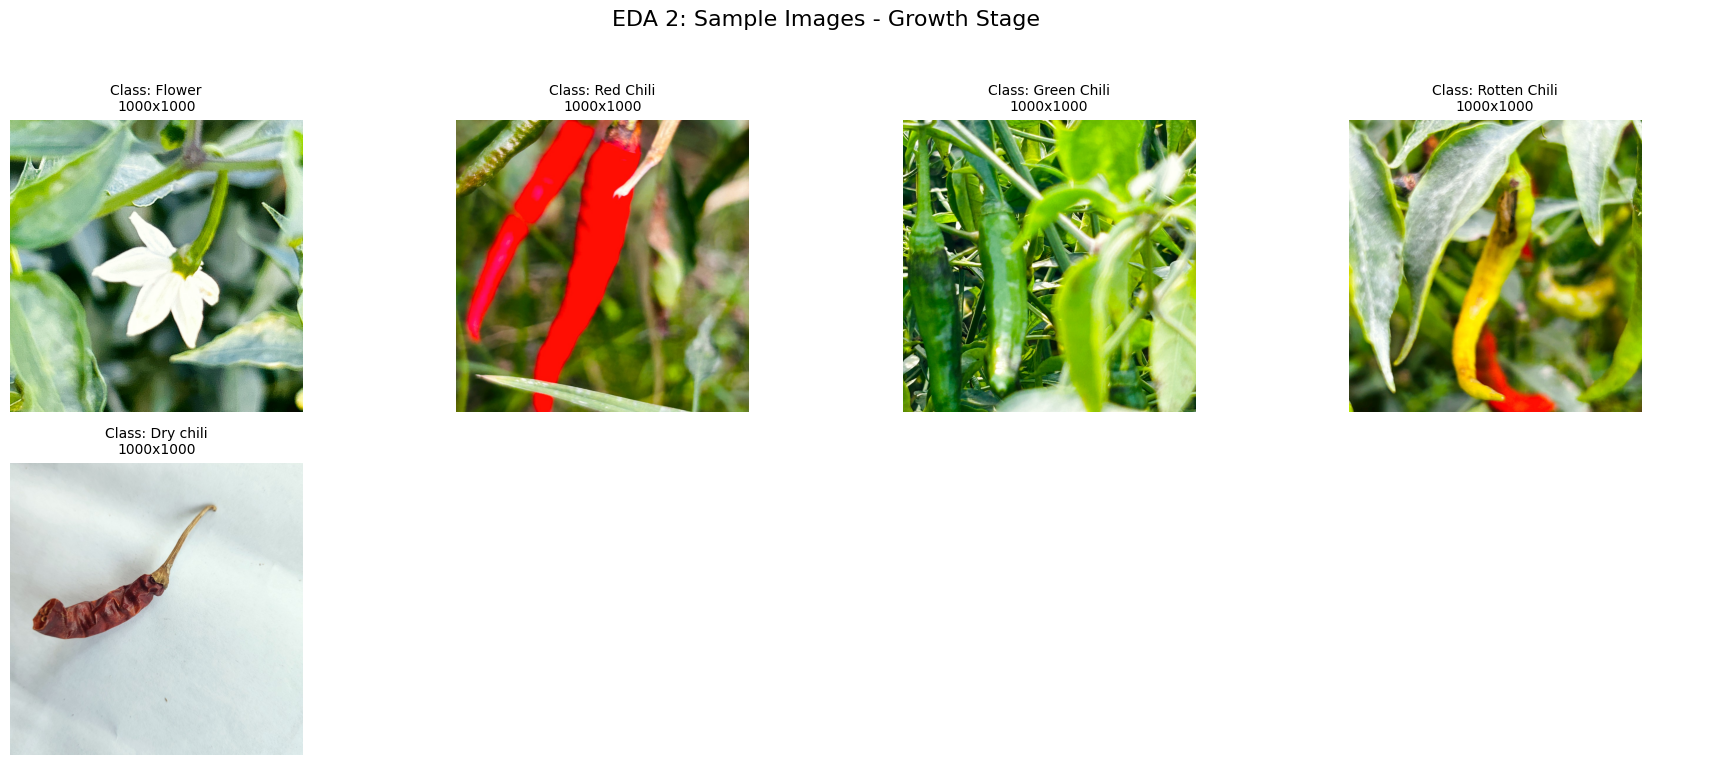

In [26]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Setup Exact Paths
path_disease = '/content/drive/MyDrive/Colab Notebooks/Chilli Plant Dataset/Chili Leaf Disease Original Dataset'
path_growth = '/content/drive/MyDrive/Colab Notebooks/Chilli Plant Dataset/Chili Growth Stage Original Dataset'

def load_chili_data(root_path):
    data = []
    if not os.path.exists(root_path):
        print(f"Path not found: {root_path}")
        return pd.DataFrame()

    # Get subfolders
    folders = [f for f in os.listdir(root_path) if os.path.isdir(os.path.join(root_path, f))]

    for folder in folders:
        folder_path = os.path.join(root_path, folder)
        images = [img for img in os.listdir(folder_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        for img_name in images:
            # We FORCE the column name to be 'Class' here
            data.append({
                'Class': folder,
                'Path': os.path.join(folder_path, img_name)
            })

    df = pd.DataFrame(data)
    if df.empty:
        print(f"No images found in {root_path}")
    else:
        print(f"Loaded {len(df)} images from {os.path.basename(root_path)}")
    return df

# Create DataFrames
df_disease = load_chili_data(path_disease)
df_growth = load_chili_data(path_growth)

# --- EDA OPERATION 3: Class Count with Total ---

def class_count_summary(df, title):
    if df.empty:
        print(f"No data available for {title}")
        return

    total_images = len(df)
    class_counts = df['Class'].value_counts()

    print(f"\nDataset: {title}")
    print(f"Total Images: {total_images}\n")

    summary_df = pd.DataFrame({
        'Class': class_counts.index,
        'Image Count': class_counts.values,
        'Percentage (%)': (class_counts.values / total_images * 100).round(2)
    })

    print(summary_df)
    return summary_df

# Run for both datasets
summary_disease = class_count_summary(df_disease, "Leaf Disease Dataset")
summary_growth = class_count_summary(df_growth, "Growth Stage Dataset")


def plot_percentage(summary_df, title):
    plt.figure(figsize=(8, 8))
    plt.pie(summary_df['Image Count'], labels=summary_df['Class'], autopct='%1.1f%%')
    plt.title(f'Class Distribution Percentage - {title}')
    plt.show()

plot_percentage(summary_disease, "Leaf Disease")
plot_percentage(summary_growth, "Growth Stage")

# --- EDA OPERATION 1: Class Distribution ---
def plot_distribution(df, title):
    if 'Class' not in df.columns or df.empty:
        print(f"Skipping Distribution for {title}: Data missing.")
        return

    plt.figure(figsize=(12, 5))
    # Using value_counts() ensures we have data to plot
    sns.countplot(data=df, x='Class', hue='Class', palette='viridis', legend=False)
    plt.title(f'EDA 1: Class Distribution - {title}', fontsize=14)
    plt.xticks(rotation=45)
    plt.ylabel('Image Count')
    plt.show()

# --- EDA OPERATION 2: Visual Grid ---
def show_visual_grid(df, title):
    if 'Class' not in df.columns or df.empty:
        print(f"Skipping Visual Grid for {title}: Data missing.")
        return

    classes = df['Class'].unique()
    num_classes = len(classes)
    cols = 4
    rows = int(np.ceil(num_classes / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
    axes = axes.flatten()

    for i, cls in enumerate(classes):
        img_info = df[df['Class'] == cls].iloc[0]
        img = cv2.imread(img_info['Path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[i].imshow(img)
        axes[i].set_title(f"Class: {cls}\n{img.shape[1]}x{img.shape[0]}", fontsize=10)
        axes[i].axis('off')

    # Clean up empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f"EDA 2: Sample Images - {title}", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Execute Operations
plot_distribution(df_disease, "Leaf Disease")
show_visual_grid(df_disease, "Leaf Disease")

plot_distribution(df_growth, "Growth Stage")
show_visual_grid(df_growth, "Growth Stage")

**Image Size Distribution**                                     
We checked image size consistency to determine if resizing is required before training.

In [27]:
from PIL import Image

def check_image_sizes_fast(df, title, sample_size=50):
    sizes = set()

    # Only check very small sample
    sample_df = df.sample(min(sample_size, len(df)))

    for path in sample_df['Path']:
        try:
            with Image.open(path) as img:
                sizes.add(img.size)  # (width, height)
        except:
            continue

    print(f"\n📊 {title} - Unique Image Sizes Found:")
    for size in sizes:
        print(size)

    if len(sizes) == 1:
        print("\n✅ All images are of same size")
    else:
        print("\n⚠️ Images have different sizes → Resizing needed")
check_image_sizes_fast(df_disease, "Leaf Disease")
check_image_sizes_fast(df_growth, "Growth Stage")


📊 Leaf Disease - Unique Image Sizes Found:
(1000, 1000)

✅ All images are of same size

📊 Growth Stage - Unique Image Sizes Found:
(1000, 1000)

✅ All images are of same size


**Corrupted Image Check**                                   
We checked for corrupted images to ensure data quality before training.

In [ ]:
from PIL import Image
import random

def check_corrupted_images_fast(df, sample_size=None):
    corrupted = []

    # Optional sampling (VERY IMPORTANT for speed)
    paths = df['Path'].tolist()
    if sample_size:
        paths = random.sample(paths, min(sample_size, len(paths)))

    for path in paths:
        try:
            with Image.open(path) as img:
                img.verify()  # verifies without loading full image
        except:
            corrupted.append(path)

    print(f"Checked Images: {len(paths)}")
    print(f"Total Corrupted Images: {len(corrupted)}")

    return corrupted

check_corrupted_images_fast(df_disease, sample_size=200)
check_corrupted_images_fast(df_growth, sample_size=200)

Checked Images: 200
Total Corrupted Images: 0
Checked Images: 200
Total Corrupted Images: 0


[]

**Class Imbalance Percentage**                             
We analyzed percentage distribution to identify class imbalance in the dataset.


 Leaf Disease - Class Percentage:

Class
Healthy Leaf            24.68
Nutrition Deficiency    23.92
Curl Virus              22.79
White spot              10.51
Cercospora Leaf Spot     9.70
Bacterial Spot           8.41
Name: proportion, dtype: float64


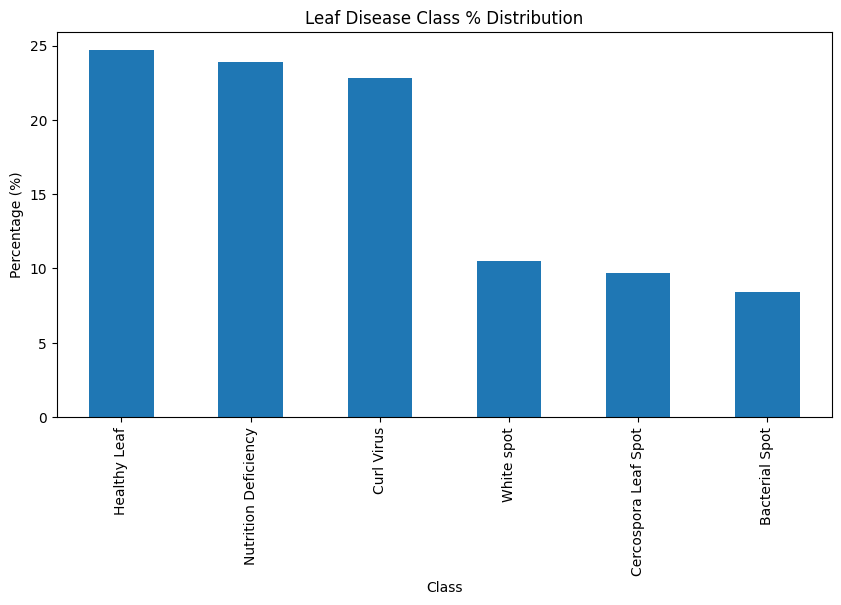


 Growth Stage - Class Percentage:

Class
Dry chili       23.92
Flower          23.16
Rotten Chili    22.11
Green Chili     19.14
Red Chili       11.67
Name: proportion, dtype: float64


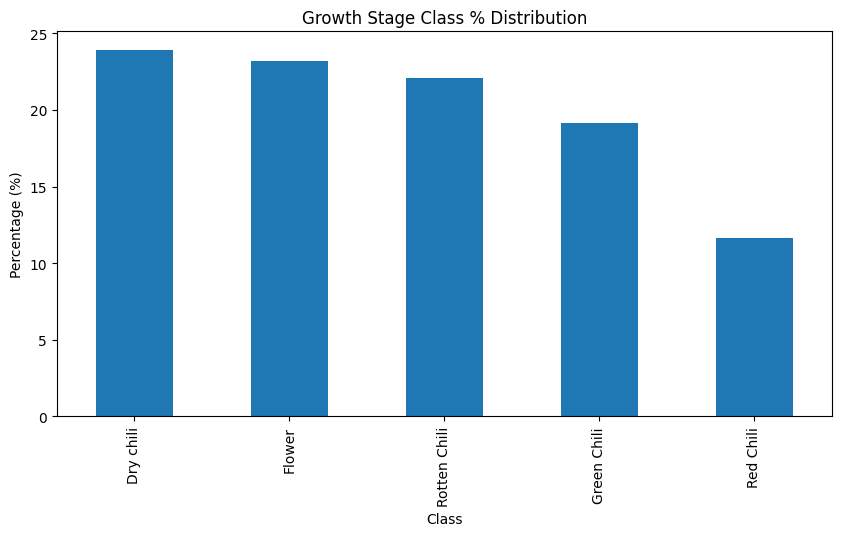

In [28]:
def class_percentage(df, title):
    total = len(df)
    percent = df['Class'].value_counts(normalize=True) * 100

    print(f"\n {title} - Class Percentage:\n")
    print(percent.round(2))

    percent.plot(kind='bar', figsize=(10,5), title=f"{title} Class % Distribution")
    plt.ylabel("Percentage (%)")
    plt.show()

# Run
class_percentage(df_disease, "Leaf Disease")
class_percentage(df_growth, "Growth Stage")

**Pixel Analysis**

Pixel intensity analysis helps understand color distribution, which is useful for preprocessing and normalization.   

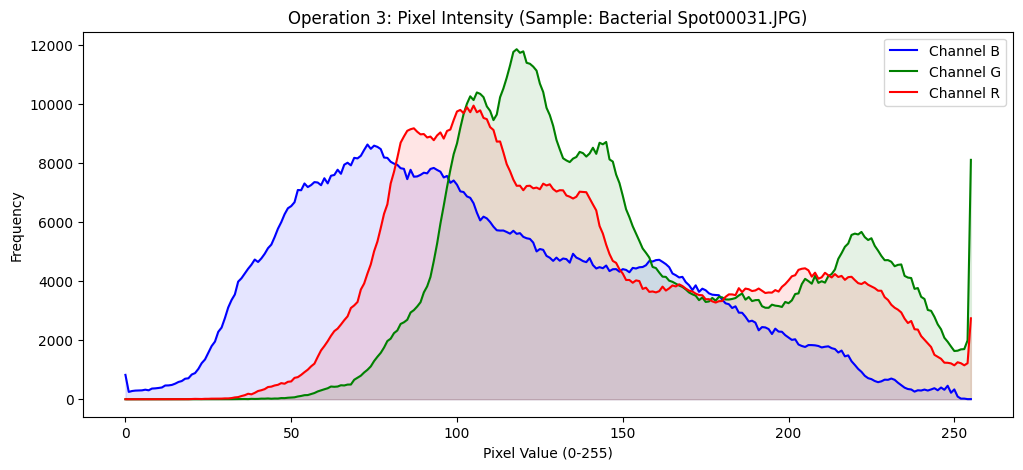

In [29]:
def plot_color_analysis(df, title):
    if df.empty:
        print(f"Skipping color analysis for {title}: DataFrame is empty.")
        return
    # Sample a random image
    sample_path = df['Path'].sample(1).values[0]
    img = cv2.imread(sample_path)

    plt.figure(figsize=(12, 5))
    colors = ('b', 'g', 'r')
    for i, col in enumerate(colors):
        hist = cv2.calcHist([img], [i], None, [256], [0, 256])
        plt.plot(hist, color=col, label=f'Channel {col.upper()}')
        plt.fill_between(range(256), hist.flatten(), color=col, alpha=0.1)

    plt.title(f"Operation 3: Pixel Intensity (Sample: {os.path.basename(sample_path)})")
    plt.xlabel('Pixel Value (0-255)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

plot_color_analysis(df_disease, "Disease Sample Analysis")

🔹 X-axis (Pixel Value: 0–255)
0 → very dark (black)
255 → very bright (white)
Middle values → shades of color                           

🔹 Y-axis (Frequency)
Number of pixels having that intensity value